# **Queues**

- A queue is a linear data structure that follows the FIFO (First-In-First-Out) principle. The first element added is the first one to be removed - like a line at a coffee shop.

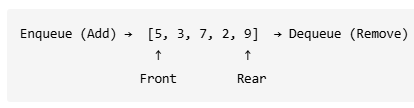

In [27]:
class Node:
    def __init__(self, val):
        self.val = val      
        self.next = None   
        
class LinkedList:
    def __init__(self):
        self.head = None    
        self.tail = None    
    
    def push(self, val): # enqueue
        newnode = Node(val)
        if self.tail is None:
            self.head = self.tail = newnode
        else:        
            self.tail.next = newnode
            self.tail = newnode            
    
    def front(self):
        return None if self.head is None else self.head.val
    
    def pop(self): # dequeue
        if self.head is None:
            print("Queue is Empty")
            return None
        val = self.head.val
        temp = self.head
        self.head = temp.next
        del temp
        if self.head is None:
            self.tail = None
        return val     
    
    def is_empty(self):
        return self.head is None
    
    def printll(self):
        """Print the entire linked list"""
        temp = self.head
        while temp is not None:
            print(f"{temp.val} ->", end=" ")
            temp = temp.next
        print("NULL")

In [28]:
q = LinkedList()
# Test on empty queue
print("Front on empty:", q.front())  # Should handle gracefully
print("Pop on empty:", q.pop())      # Should handle gracefully

# Test normal operations
q.push(10)
q.push(20)
q.push(30)
q.printll()  # 10 -> 20 -> 30 -> NULL

print("Front:", q.front())  # 10
print("Dequeued:", q.pop()) # 10
q.printll()  # 20 -> 30 -> NULL

print("Dequeued:", q.pop()) # 20
print("Dequeued:", q.pop()) # 30
q.printll()  # NULL

print("Is empty:", q.is_empty())  # True

Front on empty: None
Queue is Empty
Pop on empty: None
10 -> 20 -> 30 -> NULL
Front: 10
Dequeued: 10
20 -> 30 -> NULL
Dequeued: 20
Dequeued: 30
NULL
Is empty: True


## **Design Circular Queue**

- **Leetcode Problem Number:** 622 
- [Design Circular Queue](https://leetcode.com/problems/design-circular-queue/)


In [ ]:
class MyCircularQueue:

    def __init__(self, k: int):
        self.cap = k
        self.cq = [0] * k   # Pre-allocate with capacity k
        self.front = 0
        self.rear = -1
        self.size = 0       # Track current number of elements

    def enQueue(self, value: int) -> bool:
        if self.isFull():
            return False
        self.rear = (self.rear + 1) % self.cap
        self.cq[self.rear] = value
        self.size +=1
        return True
    def deQueue(self) -> bool:
        if self.isEmpty():
            return False
        self.front = (self.front + 1) % self.cap
        self.size -=1
        return True
    
    def Front(self) -> int:
        return -1 if self.isEmpty() else self.cq[self.front]

    def Rear(self) -> int:
        return -1 if self.isEmpty() else self.cq[self.rear]

    def isEmpty(self) -> bool:
        return self.size == 0

    def isFull(self) -> bool:
        return self.size == self.cap 


In [4]:
# Create a circular queue with capacity 3
cq = MyCircularQueue(3)

# Test enQueue
print(cq.enQueue(1))   # True - adds 1
print(cq.enQueue(2))   # True - adds 2
print(cq.enQueue(3))   # True - adds 3
print(cq.enQueue(4))   # False - queue is full

# Test isFull and isEmpty
print(cq.isFull())     # True
print(cq.isEmpty())    # False

# Test Front and Rear
print(cq.Front())      # 1
print(cq.Rear())       # 3

# Test deQueue
print(cq.deQueue())    # True - removes 1
print(cq.Front())      # 2

# Add another element
print(cq.enQueue(4))   # True - adds 4
print(cq.Rear())       # 4

# Dequeue all
print(cq.deQueue())    # True - removes 2
print(cq.deQueue())    # True - removes 3
print(cq.deQueue())    # True - removes 4
print(cq.isEmpty())    # True
print(cq.deQueue())    # False - queue is empty
print(cq.Front())      # -1 (empty)

True
True
True
False
True
False
1
3
True
2
True
4
True
True
True
True
False
-1


## **Implement Stack using Queues**

- **Leetcode Problem Number:** 225 
- [Implement Stack using Queues](https://leetcode.com/problems/implement-stack-using-queues/)


In [ ]:
class MyStack:

    def __init__(self):
        # Initialize two queues: q is the main queue, hq is the helper queue
        self.q = [] 
        self.hq = []
        
    def push(self, x: int) -> None:
        # Add the new element to the helper queue first
        self.hq.append(x)
        
        # Transfer all existing elements from main queue to helper queue
        # This places them behind the new element
        while self.q:
            self.hq.append(self.q.pop(0))
        
        # Swap the queues: helper becomes main, main becomes helper
        # Now the new element is at the front of the main queue
        self.q, self.hq = self.hq, self.q
    
    # def push(self, x : int) -> None:
    #     while self.q:
    #         self.hq.append(self.q.pop(0))
    #     self.q.append(x)
    #     while self.hq:
    #         self.q.append(self.hq.pop(0))
            
    def pop(self) -> int:
        # Store the front element (stack top)
        val = self.q[0]
        # Remove it from the queue
        self.q.pop(0)
        # Return the removed element
        return val

    def top(self) -> int:
        # Return the front element without removing it
        return self.q[0]

    def empty(self) -> bool:
        # Return True if queue is empty, False otherwise
        return not self.q

In [49]:
stack = MyStack()          # Create the stack
stack.push(5)              # Stack now has: [5]
stack.push(10)             # Stack now has: [10, 5]
stack.push(15)             # Stack now has: [15, 10, 5]
print(stack.top())         # Prints 15 (doesn't remove it)
print(stack.pop())         # Prints 15 and removes it
print(stack.pop())         # Prints 10 and removes it
print(stack.empty())       # Prints False (still has 5)

15
15
10
False


## **Implement Queues using Stack **

- **Leetcode Problem Number:** 232 
- [Implement Queues using Stack](https://leetcode.com/problems/implement-queue-using-stacks/)


In [50]:
class MyQueue:

    def __init__(self):
        self.s = []
        self.hs = []
        
    def push(self, x: int) -> None:
        self.s.append(x)
        
    def pop(self) -> int:
        pass
    def peek(self) -> int:
        pass
    def empty(self) -> bool:
        pass
        

## **Number of Students Unable to Eat Lunch **

- **Leetcode Problem Number:** 1700 
- [Number of Students Unable to Eat Lunch](https://leetcode.com/problems/number-of-students-unable-to-eat-lunch/)

## **Example:**
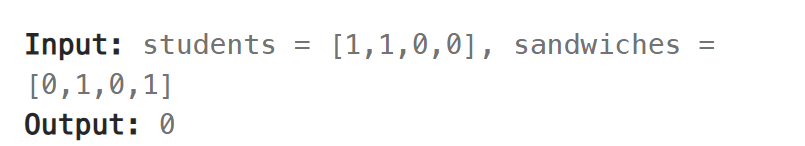

In [ ]:
# Big O(n^2)
students= [1,1,0,0]
sandwiches = [0,1,0,1]

count = 0
while students and count < len(students):
    if students[0] == sandwiches[0]:
        students.pop(0)
        sandwiches.pop(0)
        count = 0
    else:
        students.append(students.pop(0))
        count+=1
print(len(students))


0


In [ ]:
# Big O(n)
students= [1,1,0,0]
sandwiches = [0,1,0,1]

s0 = students.count(0)
s1 = students.count(1)

for s in sandwiches:
    if s == 0:
        if s0 ==0:
            break
        s0-=1
    else:
        if s1 == 0:
            break
        s1-=1
print(s0+s1)

0


In [8]:
from collections import Counter
cnt = Counter(students)

cnt[1]

2

In [9]:
# Big O(n)  and Cleaner code
def countStudents(students, sandwiches):
    cnt = Counter(students)
    res = len(students)
    for s in sandwiches:
        if cnt[s] > 0:
           res -=1
           cnt[s] -=1
        else:
            return res 
    return res

## **First Unique Character in a String**

- **Leetcode Problem Number:** 387 
- [First Unique Character in a String](https://leetcode.com/problems/first-unique-character-in-a-string/)

## **Example:**
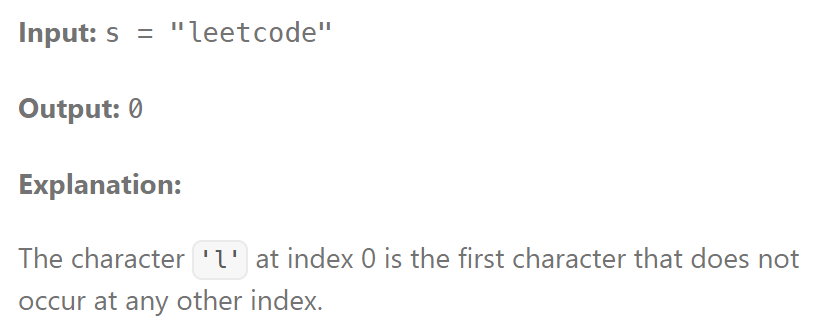

In [ ]:
from collections import defaultdict
def firstUniqChar(s: str) -> int:
    # count = set()
    count = defaultdict(int)
    que = []
    for i, ch in enumerate(s):
        count[ch] +=1
        que.append(i)
        while que and count[s[que[0]]] > 1:
            que.pop(0)
    return que if que else -1
    

In [40]:
s = "aabb"
fu = firstUniqChar(s)
print(fu)

-1


In [47]:
from collections import Counter

s = "leetcode"

print(Counter(s))

count = Counter(s)

count['e']


Counter({'e': 3, 'l': 1, 't': 1, 'c': 1, 'o': 1, 'd': 1})


3

In [51]:
from collections import Counter
def firstUniqChar(s: str) -> int:
    count = Counter(s)
    for i, ch in enumerate(s):
        if count[ch] == 1:
            return i
    return -1

In [54]:
s = "leetcode"
fu = firstUniqChar(s)
print(fu)

0


In [58]:
s = "qdadaaaaaaaabbb"
fu = firstUniqChar(s)
print(fu)

0


## **Sliding Window Maximum**

- **Leetcode Problem Number:** 239
- [Sliding Window Maximum](https://leetcode.com/problems/sliding-window-maximum/)

## **Example:**
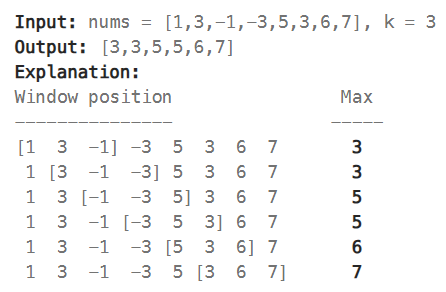